In [1]:
#!pip install datasets
#!pip install --upgrade --quiet pip
#!pip install --upgrade --quiet datasets[audio] transformers accelerate evaluate jiwer tensorboard gradio
#!pip install --upgrade transformers

In [2]:
import os
import torch

from pathlib import Path

from dataloader import Dataloader
from model_wrapper import WhisperWrapper, IntermediateLayerGetter
from model_evaluator import WhisperEvaluator
from experiment import run_experiment, identify_influential_layers
from feature_density_estimator import FeatureDensityEstimator

avail_dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
avail_dev = torch.device("xpu" if torch.xpu.is_available() else avail_dev)
print("Using device: ", avail_dev)

OSError: [WinError 126] The specified module could not be found. Error loading "c:\Users\erick\micromamba\envs\ml\lib\site-packages\torch\lib\c10_xpu.dll" or one of its dependencies.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

#whisper_path = "/content/drive/My Drive/Whisper"
whisper_path = Path(r"C:\Users\erick\Models\Whisper")
print(os.listdir(whisper_path))

['processor_1', 'tokenizer_1', 'whisper_1']


In [ ]:
# Create model
model_wrap = WhisperWrapper(device=avail_dev)
# Create evaluator
whisper_evaluator = WhisperEvaluator(model = model_wrap.model_cond_gen, processor = model_wrap.processor)
# Create the feature density estimator
fde = FeatureDensityEstimator(model_wrap)

In [ ]:
# Load baseline data
featured_df, featured_audios = Dataloader.load_dataset_raw_uq(partition_type = "fine_tuning_partition",
                                                              partition_id = "fine_tuning_partition")

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

In [ ]:
# Get all the layers
layer_names = IntermediateLayerGetter.get_layer_names(model_wrap.model)
# Select only the layer norms
layer_names = [name for name in layer_names if (("layer_norm" in name) and not("attn" in name))]
# Get the layer influence scores
#layer_influence_score = identify_influential_layers(model_wrap, layer_names, featured_audios)
#
#print("Most influential layers:")
#print(60*"-")
#for key, value in layer_influence_score.items():
#    print(f"{key}:\t\t{value:.4f}")
#    print(60*"-")
#print(list(layer_influence_score.keys())) 

In [ ]:
#calibration_ds, calibration_audios = Dataloader.load_uq_partitions("calibration")
#finetune_ds, finetune_audios = Dataloader.load_uq_partitions("fine-tune")
test_ds, test_audios = Dataloader.load_uq_partitions("test", 1, 11)

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

In [ ]:
# Validate that using .last_hidden_state is equal to using the layer name
hooked_model = IntermediateLayerGetter(model_wrap.model, ["decoder.layer_norm"])
input_features = model_wrap.feature_extractor(test_audios[0][0], return_tensors="pt", sampling_rate = model_wrap.sampling_rate).input_features.to(avail_dev)
decoder_input_ids = torch.tensor([[1, 1]], device=avail_dev) * model_wrap.model.config.decoder_start_token_id
by_attr = model_wrap.model(input_features, decoder_input_ids = decoder_input_ids).last_hidden_state
by_hook = hooked_model(input_features, decoder_input_ids = decoder_input_ids)[0]
print("By attr: ", by_attr.shape)
print("By hook: ", by_hook["decoder.layer_norm"].shape)
print(torch.equal(by_attr, by_hook["decoder.layer_norm"]))

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.43.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


By attr:  torch.Size([1, 2, 768])
By hook:  torch.Size([1, 2, 768])
True


Extracting embeddings:   0%|          | 0/2000 [00:00<?, ?it/s]

Processing partitions:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

You have passed task=transcribe, but also have set `forced_decoder_ids` to [(1, 50262), (2, 50359), (3, 50363)] which creates a conflict. `forced_decoder_ids` will be ignored in favor of task=transcribe.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
c:\Users\erick\micromamba\envs\ml\lib\site-packages\transformers\pytorch_utils.py:334: UserWarning: Aten Op fallback from XPU to CPU happends. This may have performance implications. If need debug the fallback ops please set environment variable `PYTORCH_DEBUG_XPU_FALLBACK=1`  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen\xpu\RegisterXPU.cpp:7617.)
  return torch.isin(elements, test_elements)


Partition 0 - Mean WER: 0.3527, Std WER: 1.3312, Pearson correlation coefficient: 0.0266


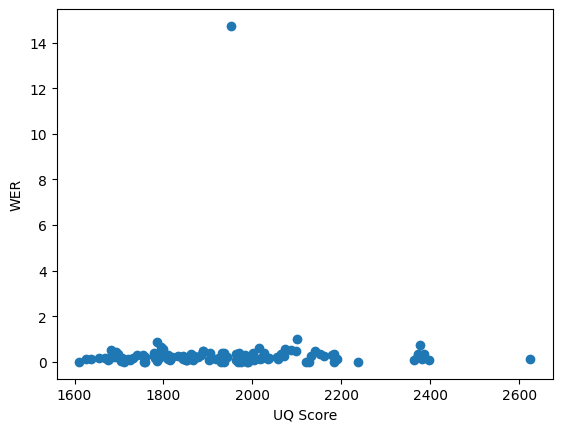

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 1 - Mean WER: 0.2259, Std WER: 0.1855, Pearson correlation coefficient: -0.0862


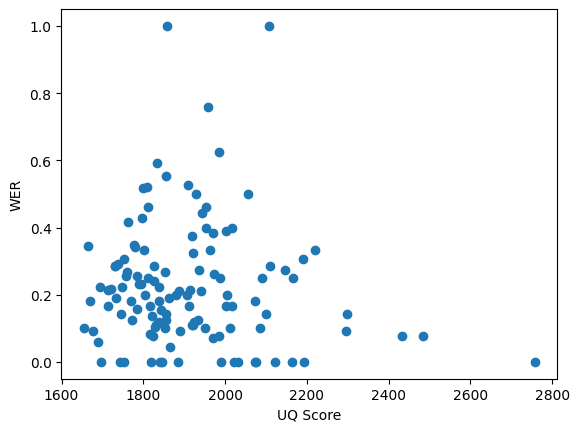

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 2 - Mean WER: 0.2600, Std WER: 0.2212, Pearson correlation coefficient: 0.3470


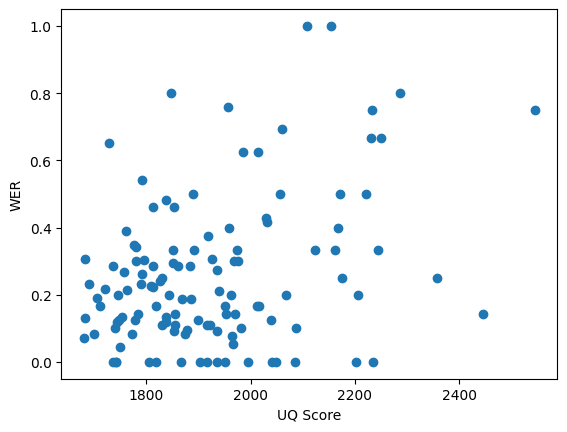

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 3 - Mean WER: 0.2226, Std WER: 0.1660, Pearson correlation coefficient: 0.0878


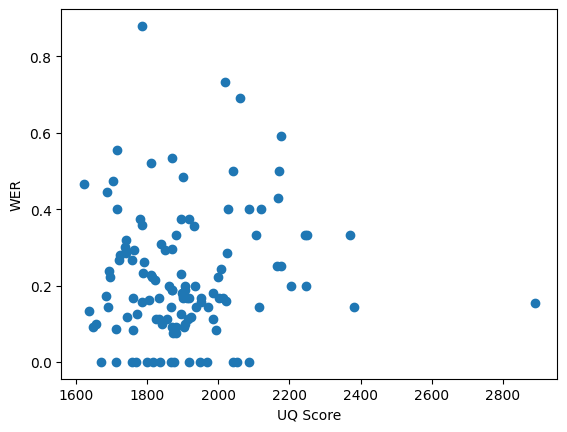

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 4 - Mean WER: 0.3551, Std WER: 1.3315, Pearson correlation coefficient: 0.0263


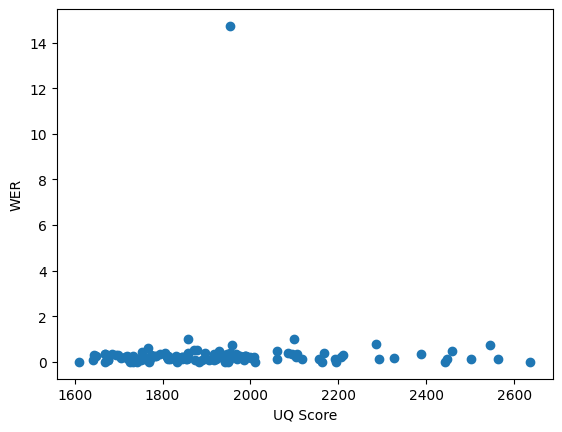

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 5 - Mean WER: 0.2332, Std WER: 0.1909, Pearson correlation coefficient: 0.0885


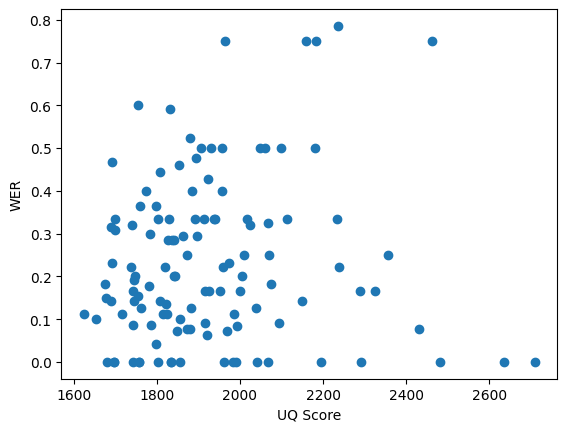

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 6 - Mean WER: 0.2483, Std WER: 0.1952, Pearson correlation coefficient: 0.0131


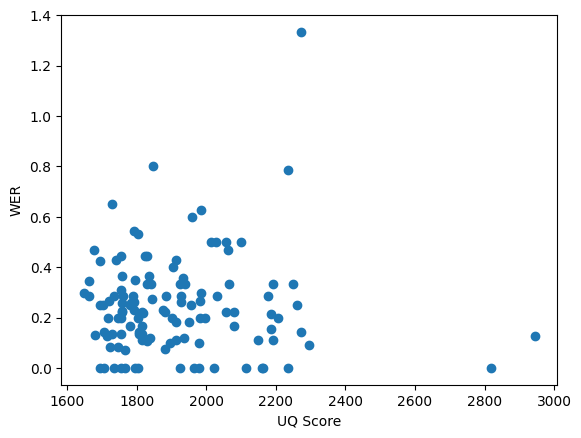

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 7 - Mean WER: 0.2307, Std WER: 0.1888, Pearson correlation coefficient: 0.0986


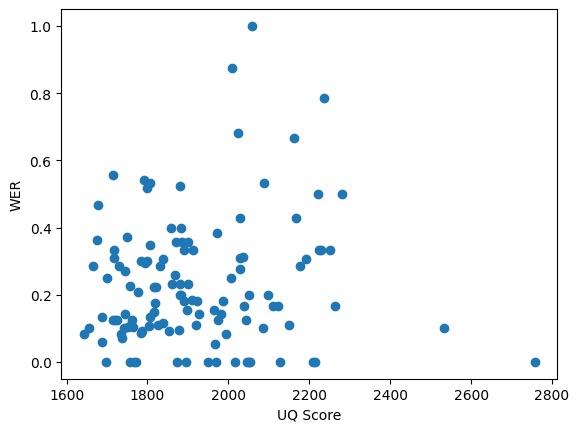

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 8 - Mean WER: 0.2183, Std WER: 0.1795, Pearson correlation coefficient: 0.1818


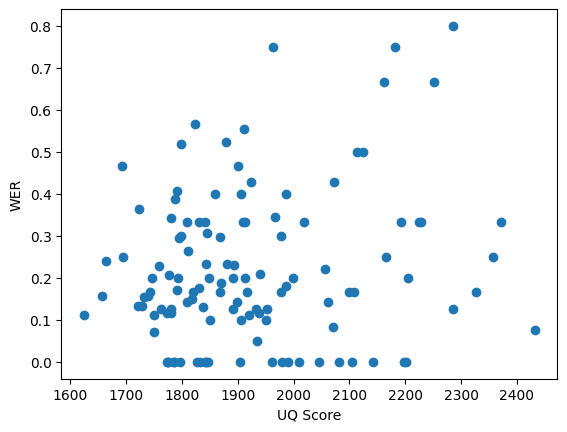

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 9 - Mean WER: 0.2377, Std WER: 0.1919, Pearson correlation coefficient: 0.1814


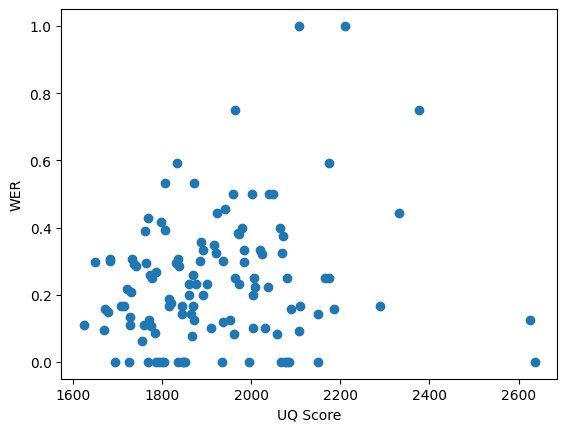

=============== Results ===============
    Partition         R  Mean WER   Std WER
0          0  0.026608  0.352731  1.331211
1          1 -0.086250  0.225894  0.185501
2          2  0.346958  0.259999  0.221210
3          3  0.087761  0.222611  0.165971
4          4  0.026297  0.355099  1.331508
5          5  0.088455  0.233173  0.190937
6          6  0.013096  0.248305  0.195212
7          7  0.098620  0.230697  0.188759
8          8  0.181844  0.218335  0.179471
9          9  0.181449  0.237738  0.191874
=============== Mean results ===============
 Partition    4.500000
R            0.096484
Mean WER     0.258458
Std WER      0.418165
dtype: float64


In [ ]:
# Single layers single channel mean reduction
kwargs = {  "target_layers":      ['decoder.layers.0.final_layer_norm'],
            "embedding_filter":   lambda x: x[0, 0, :].cpu().detach()
        }
name = "decl_0_fln-baseline"

run_experiment( fde, whisper_evaluator, featured_audios, test_ds, test_audios,
                name, f"results/{name}", **kwargs)

Extracting embeddings:   0%|          | 0/2000 [00:00<?, ?it/s]

Processing partitions:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 0 - Mean WER: 0.3527, Std WER: 1.3312, Pearson correlation coefficient: 0.0988


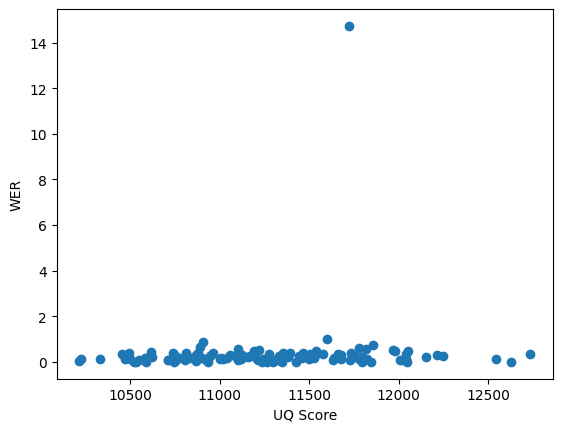

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 1 - Mean WER: 0.2259, Std WER: 0.1855, Pearson correlation coefficient: 0.0006


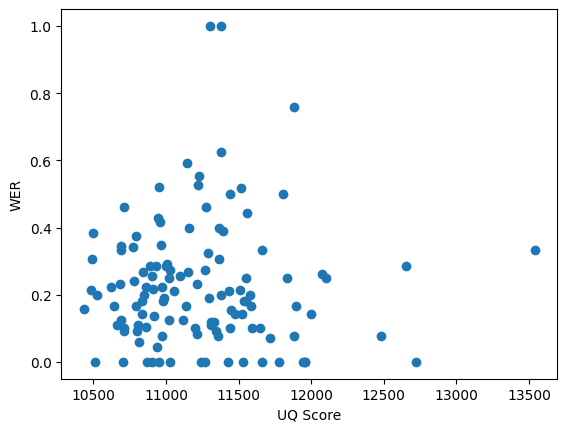

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 2 - Mean WER: 0.2600, Std WER: 0.2212, Pearson correlation coefficient: 0.3636


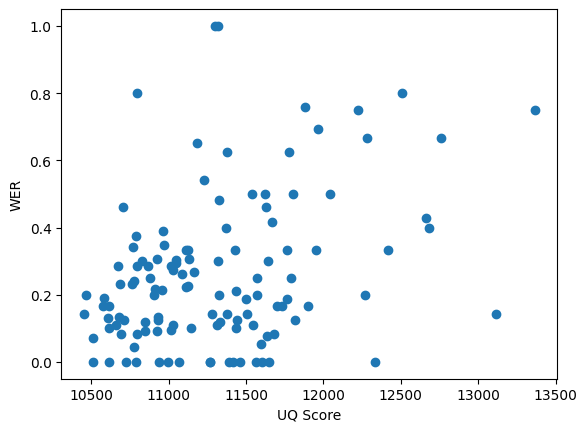

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 3 - Mean WER: 0.2226, Std WER: 0.1660, Pearson correlation coefficient: 0.1653


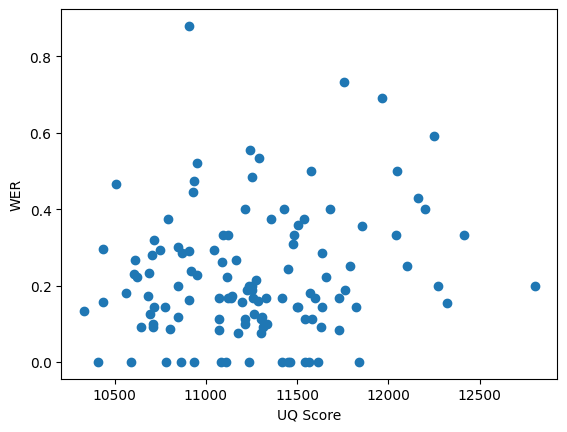

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 4 - Mean WER: 0.3551, Std WER: 1.3315, Pearson correlation coefficient: 0.1080


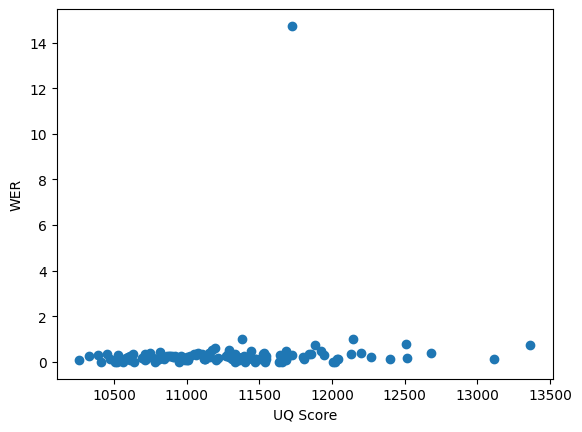

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 5 - Mean WER: 0.2332, Std WER: 0.1909, Pearson correlation coefficient: 0.2718


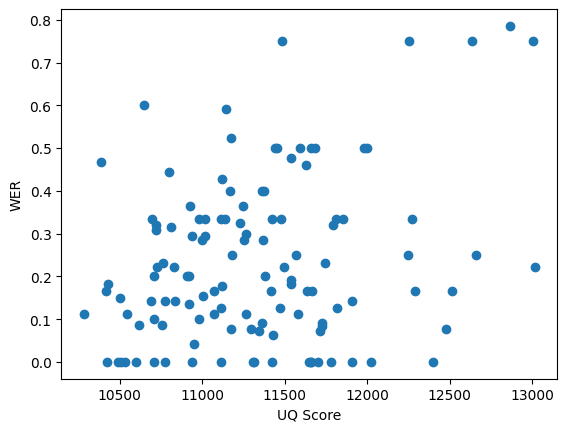

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

In [ ]:
# Multiple layers single channel mean reduction
fde = FeatureDensityEstimator(model_wrap)
kwargs = {  "target_layers":      ['decoder.layers.0.final_layer_norm', 'decoder.layers.2.final_layer_norm', 
                                   'decoder.layers.11.final_layer_norm'],
            "embedding_filter":   lambda x: x.mean(dim = (0, 1)).cpu().detach()
        }
name = "top_3_layers-mean"

run_experiment( fde, whisper_evaluator, featured_audios, test_ds, test_audios,
                name, f"results/{name}", **kwargs)

Extracting embeddings:   0%|          | 0/2000 [00:00<?, ?it/s]

Processing partitions:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 0 - Mean WER: 0.3527, Std WER: 1.3312, Pearson correlation coefficient: 0.0595


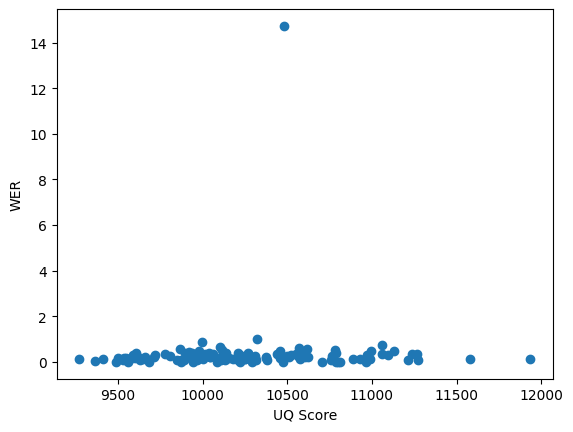

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 1 - Mean WER: 0.2259, Std WER: 0.1855, Pearson correlation coefficient: -0.0861


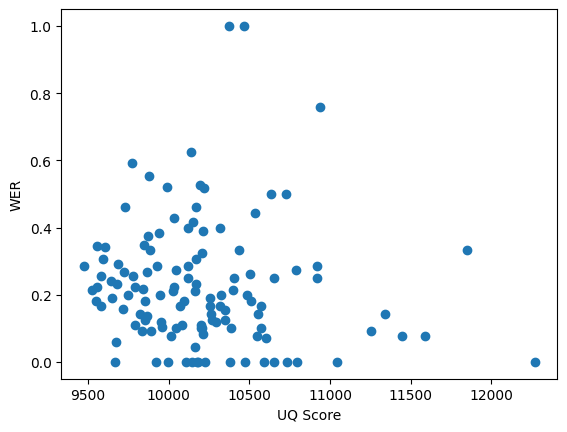

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 2 - Mean WER: 0.2600, Std WER: 0.2212, Pearson correlation coefficient: 0.3666


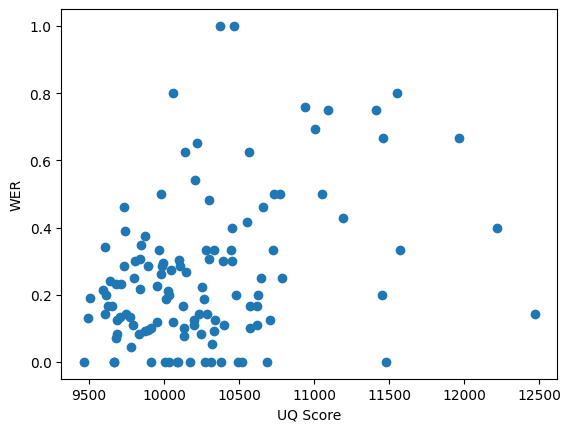

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 3 - Mean WER: 0.2226, Std WER: 0.1660, Pearson correlation coefficient: 0.1274


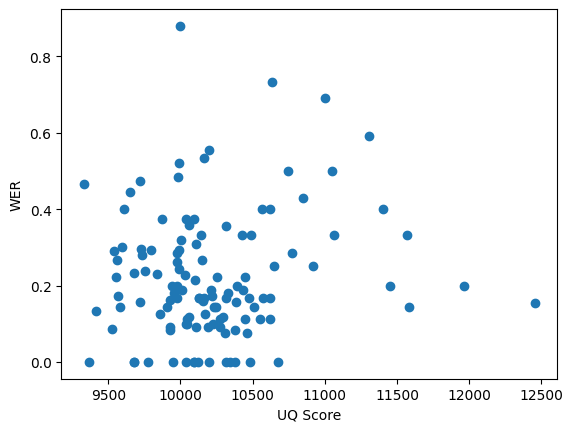

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 4 - Mean WER: 0.3551, Std WER: 1.3315, Pearson correlation coefficient: 0.0546


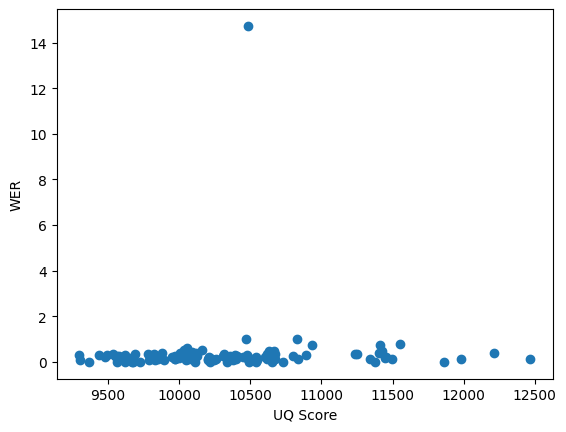

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 5 - Mean WER: 0.2332, Std WER: 0.1909, Pearson correlation coefficient: 0.2119


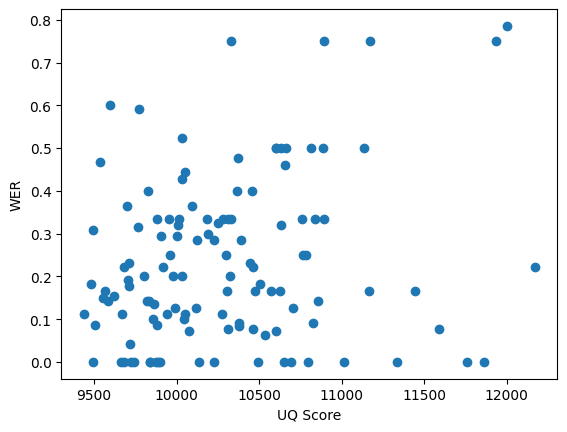

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 6 - Mean WER: 0.2483, Std WER: 0.1952, Pearson correlation coefficient: 0.1932


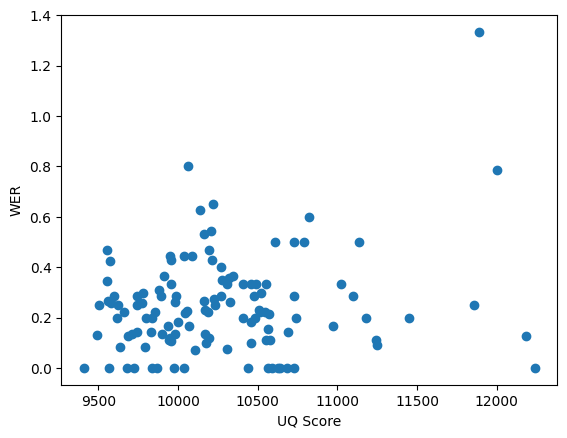

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 7 - Mean WER: 0.2307, Std WER: 0.1888, Pearson correlation coefficient: 0.2040


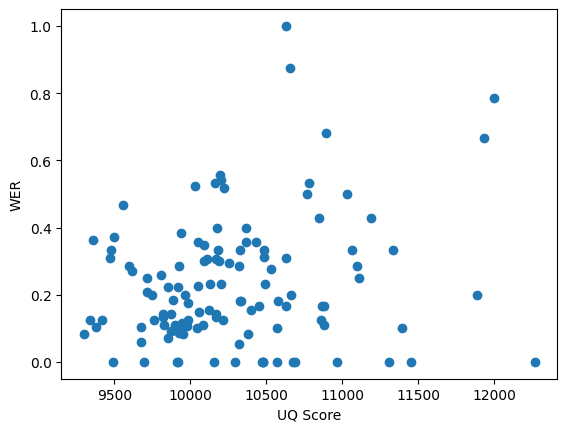

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 8 - Mean WER: 0.2183, Std WER: 0.1795, Pearson correlation coefficient: 0.2559


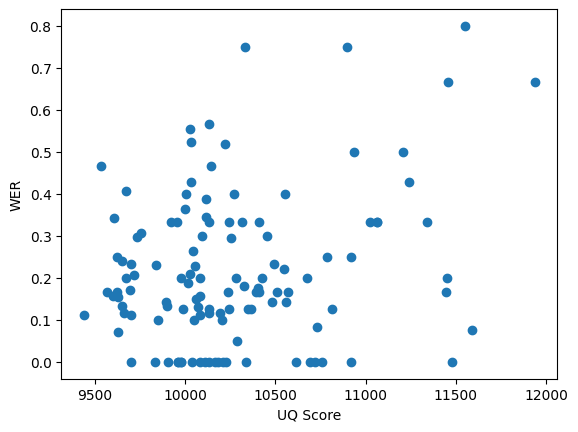

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

Partition 9 - Mean WER: 0.2377, Std WER: 0.1919, Pearson correlation coefficient: 0.1747


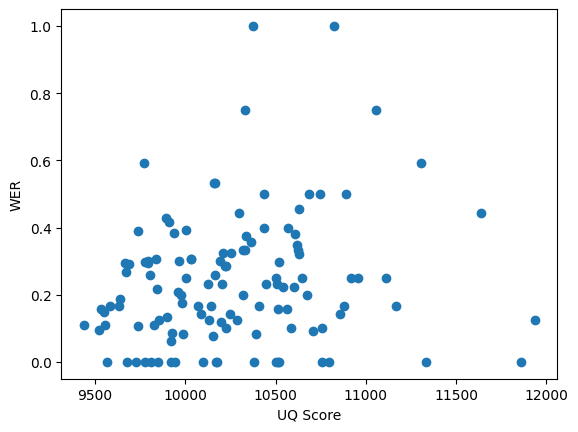

=============== Results ===============
    Partition         R  Mean WER   Std WER
0          0  0.059547  0.352731  1.331211
1          1 -0.086112  0.225894  0.185501
2          2  0.366609  0.259999  0.221210
3          3  0.127378  0.222611  0.165971
4          4  0.054602  0.355099  1.331508
5          5  0.211935  0.233173  0.190937
6          6  0.193245  0.248305  0.195212
7          7  0.203968  0.230697  0.188759
8          8  0.255932  0.218335  0.179471
9          9  0.174691  0.237738  0.191874
=============== Mean results ===============
 Partition    4.500000
R            0.156179
Mean WER     0.258458
Std WER      0.418165
dtype: float64


<Figure size 640x480 with 0 Axes>

In [ ]:
# Multiple layers single channel (last_hidden_state[0, 0, :])
fde = FeatureDensityEstimator(model_wrap)
kwargs = {  "target_layers":      ['decoder.layers.0.final_layer_norm', 'decoder.layers.2.final_layer_norm', 
                                   'decoder.layers.11.final_layer_norm'],
            "embedding_filter":   lambda x: x[0, 0, :].cpu().detach()
        }
name = "top_3_layers-last_hidden_state"

run_experiment( fde, whisper_evaluator, featured_audios, test_ds, test_audios,
                name, f"results/{name}", **kwargs)

In [ ]:
# Single layers single channel mean reduction
kwargs = {  "target_layers":      ['decoder.layers.0.final_layer_norm'],
            "embedding_filter":   lambda x: torch.flatten(x).cpu().detach()
        }
name = "decl_0_fln-flatten"

run_experiment( fde, whisper_evaluator, featured_audios, test_ds, test_audios,
                name, f"results/{name}", **kwargs)